In [1]:
"""
    simple_opf_varying_loads_diagonal.ipynb

Simple multiphase AC OPF with varying load levels using a diagonal voltage change of variables.

Formulation:
- Local-pu voltage variables ur, ui for all network nodes
- Slack voltages are fixed after the same diagonal scaling
- Nodal power balance uses Ytilde = D * Y * D in local coordinates
- Source (slack) generator has cost; PV generators have zero cost
- Voltage magnitude bounds are uniform in local per-unit
- Generator P/Q capability bounds

Load scenarios: 50%, 75%, 100%, 125% of base case.
"""

using Pkg
Pkg.activate(normpath(joinpath(@__DIR__, "..")))

using FeederFlow
using JuMP
using Ipopt
using Printf
using LinearAlgebra
using SparseArrays
include(joinpath(@__DIR__, "..", "src", "switch_admittance_patch.jl"))

# ── Parse network ─────────────────────────────────────────────────────────────
root = normpath(joinpath(@__DIR__, ".."))
path = joinpath(root, "examples", "grids", "13_bus", "IEEE13Nodeckt.dss")
# path = joinpath(root, "examples", "grids", "37_bus", "ieee37.dss")
# path = joinpath(root, "examples", "grids", "123_bus", "IEEE123Master.dss")

network = FeederFlow.parse_file(path; regulator_model=:nonideal)
ybus = FeederFlow.build_y(network; regulator_model=:nonideal, epsilon=1e-5)
v_slack = FeederFlow.source_slack(network.source, network.base)
noload = FeederFlow.compute_no_load(ybus; v_slack)

base = network.base
n_net = length(ybus.network_order)   # network (non-slack) phase nodes
n_slk = length(ybus.slack_order)     # slack phase nodes
n_total = n_net + n_slk              # total phase nodes

println("="^70)
println("SIMPLE MULTIPHASE AC OPF - VARYING LOAD SCENARIOS")
println("="^70)
println("System base: Sbase = $(base.Sbase/1e6) MVA, Vbase = $(base.Vbase/1e3) kV")
println("Network nodes: $n_net, Slack nodes: $n_slk, Total: $n_total")
println("Loads: $(length(network.loads)), Generators: $(length(network.generators))")
println()


  Activating project at `c:\Users\hoang\OneDrive - Massachusetts Institute of Technology\1. MIT\2. Projects\4. Dist OPF\multiphase_modelling\FeederFlow.jl`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ─ FeederFlow
└ @ Base.Precompilation precompilation.jl:733
[ Info: Precompiling FeederFlow [8f9c5a44-f7c9-42f9-8ef7-6f0d3dd65701] (cache misses: include_dependency fsize change (6), mismatched flags (12))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


SIMPLE MULTIPHASE AC OPF - VARYING LOAD SCENARIOS
System base: Sbase = 5.0 MVA, Vbase = 2.4017771198288433 kV
Network nodes: 38, Slack nodes: 3, Total: 41
Loads: 15, Generators: 3



In [2]:
loads = FeederFlow.build_load_model(network, ybus, noload)

LoadModel(FeederFlow.LoadContribution[FeederFlow.LoadContribution(:wye, :pq, [(26, 0)], ComplexF64[0.058 + 0.0424im], [0.9992600812897369], [0.95], [1.05], [1.0], [2.0]), FeederFlow.LoadContribution(:wye, :pq, [(15, 0)], ComplexF64[0.0132 + 0.0076im], [0.9992600812897369], [0.95], [1.05], [1.0], [2.0]), FeederFlow.LoadContribution(:wye, :pq, [(24, 0)], ComplexF64[0.097 + 0.038im], [0.9992600812897369], [0.95], [1.05], [1.0], [2.0]), FeederFlow.LoadContribution(:wye, :pq, [(4, 0)], ComplexF64[0.034 + 0.025im], [0.9992600812897369], [0.95], [1.05], [1.0], [2.0]), FeederFlow.LoadContribution(:wye, :pq, [(35, 0)], ComplexF64[0.024 + 0.018im], [0.1153312677155238], [0.95], [1.05], [1.0], [2.0]), FeederFlow.LoadContribution(:wye, :i, [(3, 0)], ComplexF64[0.034 + 0.016im], [0.9992600812897369], [0.95], [1.05], [1.0], [2.0]), FeederFlow.LoadContribution(:delta, :i, [(11, 13)], ComplexF64[0.034 + 0.0302im], [1.7320508075688772], [0.95], [1.05], [1.0], [2.0]), FeederFlow.LoadContribution(:delta,

In [20]:
# ── Voltage scale factors (bus base / system base) ────────────────────────────
# The diagonal map V = D * u converts system-base voltages into local-pu
# variables. The same scale is used to transform the full nodal admittance.
v_scale = [network.buses[bp.bus].vbase / network.base.Vbase for bp in ybus.network_order]
v_scale_slack = [network.buses[bp.bus].vbase / network.base.Vbase for bp in ybus.slack_order]
v_scale_full = vcat(v_scale, v_scale_slack)

println("--- Voltage Scale Factors (from bus bases) ---")
for i in 1:n_net
    bp = ybus.network_order[i]
    if abs(v_scale[i] - 1.0) > 1e-6
        @printf("  %-6s ph%d: scale = %.4f\n", bp.bus, bp.phase, v_scale[i])
    end
end
println()

# No-load voltages provide a stable local-pu warm start.
u_start = noload.w ./ v_scale
v_slack_local = v_slack ./ v_scale_slack

# ── Build full Y matrix (all nodes) ───────────────────────────────────────────
Y_full = Matrix(ybus.Ynet)
Y_scaled = Diagonal(v_scale_full) * Y_full * Diagonal(v_scale_full)


# ── Per-node load demand (positive = consumption, from network.loads) ─────────
function build_load_vector(network, ybus, load_factor)
    n = n_net
    s_load = zeros(ComplexF64, n)
    for load in network.loads
        nph = length(load.bus.phases)
         s_phase= complex(load.p_pu, load.q_pu) / nph
        for phase in load.bus.phases
            idx = FeederFlow.lookup_node_index(ybus, load.bus.bus, phase)
            idx > 0 || continue
            s_load[idx] += load_factor * s_phase
        end
    end
    return s_load
end

function build_load_ref_vector(network, ybus)
    n = length(ybus.network_order)
    p_load_ref = zeros(n)
    q_load_ref = zeros(n)
    for load in network.loads
        nph = length(load.bus.phases)
        p_phase = load.p_pu / nph
        q_phase = load.q_pu / nph
        for phase in load.bus.phases
            idx = FeederFlow.lookup_node_index(ybus, load.bus.bus, phase)
            idx > 0 || continue
            p_load_ref[idx] += p_phase
            q_load_ref[idx] += q_phase
        end
    end
    return p_load_ref, q_load_ref
end

# ── Generator mapping to network node indices ─────────────────────────────────
function map_generators(network, ybus)
    gen_node = Int[]
    gen_pmax = Float64[]
    gen_qmax = Float64[]
    gen_qmin = Float64[]
    gen_cost = Vector{Float64}[]
    gen_type = Symbol[]

    for gen in network.generators
        nph = length(gen.bus.phases)
        for phase in gen.bus.phases
            idx = FeederFlow.lookup_node_index(ybus, gen.bus.bus, phase)
            idx > 0 || continue
            push!(gen_node, idx)
            push!(gen_pmax, gen.p_pu / nph)
            push!(gen_qmax, gen.qmax_pu / nph)
            push!(gen_qmin, gen.qmin_pu / nph)
            push!(gen_cost, gen.cost_coeff)
            push!(gen_type, gen.generator_type)
        end
    end
    return gen_node, gen_pmax, gen_qmax, gen_qmin, gen_cost, gen_type
end

# Estimate a physically meaningful source apparent-power cap from transformer
# ratings at the slack bus, with a load-based floor for feeders without metadata.
function estimate_substation_smax(network)
    kva_candidates = Float64[]
    for tr in vcat(collect(network.transformers), collect(network.regulators))
        for w in tr.windings
            w.bus.bus == network.slack_bus || continue
            push!(kva_candidates, w.kva)
        end
    end
    raw = isempty(kva_candidates) ? 0.0 : maximum(kva_candidates) * 1000.0 / network.base.Sbase
    p_total = sum(load.p_pu for load in network.loads)
    q_total = sum(load.q_pu for load in network.loads)
    demand = hypot(p_total, q_total)
    return max(raw, 1.5 * demand + 1e-3, 0.2)
end

gen_node, gen_pmax, gen_qmax, gen_qmin, gen_cost, gen_type = map_generators(network, ybus)
n_gen_pv = length(gen_node)

# Override PV Q bounds: allow +/-40% of P rating for reactive power support
for k in 1:n_gen_pv
    p_rating = gen_pmax[k]
    gen_qmax[k] = 0.99 * p_rating
    gen_qmin[k] = -0.99 * p_rating
end

delta_deg = 60
current_limit_scale = 1.00
s_sub_max = estimate_substation_smax(network)

println("--- Generator Summary ---")
for k in 1:n_gen_pv
    bp = ybus.network_order[gen_node[k]]
    @printf("  Gen %-2d: bus=%-6s ph%d  type=%-5s  Pmax=%.4f  Q in [%.4f, %.4f]  cost_1=%.2f, cost_2=%.2f, cost_3=%.2f\n",
            k, bp.bus, bp.phase, gen_type[k], gen_pmax[k], gen_qmin[k], gen_qmax[k], gen_cost[k][1], gen_cost[k][2], gen_cost[k][3])
end

println("\n--- Slack (Source) ---")
for k in 1:n_slk
    bp = ybus.slack_order[k]
    @printf("  Slack %-2d: bus=%-6s ph%d  Vsys=%.4f pu  Vloc=%.4f pu\n",
            k, bp.bus, bp.phase, abs(v_slack[k]), abs(v_slack_local[k]))
end

println("\n--- Security Constraint Settings ---")
@printf("  Max branch angle difference: ±%.1f deg\n", delta_deg)
@printf("  Branch current scale:        %.2f x rating\n", current_limit_scale)
@printf("  Substation apparent limit:   %.4f pu\n", s_sub_max)
println()

--- Voltage Scale Factors (from bus bases) ---
  634    ph1: scale = 0.1154
  634    ph2: scale = 0.1154
  634    ph3: scale = 0.1154

--- Generator Summary ---
  Gen 1 : bus=675    ph1  type=pv     Pmax=0.0167  Q in [-0.0165, 0.0165]  cost_1=0.20, cost_2=5.00, cost_3=0.00
  Gen 2 : bus=675    ph2  type=pv     Pmax=0.0167  Q in [-0.0165, 0.0165]  cost_1=0.20, cost_2=5.00, cost_3=0.00
  Gen 3 : bus=675    ph3  type=pv     Pmax=0.0167  Q in [-0.0165, 0.0165]  cost_1=0.20, cost_2=5.00, cost_3=0.00
  Gen 4 : bus=671    ph1  type=pv     Pmax=0.0233  Q in [-0.0231, 0.0231]  cost_1=0.20, cost_2=5.00, cost_3=0.00
  Gen 5 : bus=671    ph2  type=pv     Pmax=0.0233  Q in [-0.0231, 0.0231]  cost_1=0.20, cost_2=5.00, cost_3=0.00
  Gen 6 : bus=671    ph3  type=pv     Pmax=0.0233  Q in [-0.0231, 0.0231]  cost_1=0.20, cost_2=5.00, cost_3=0.00
  Gen 7 : bus=634    ph1  type=pv     Pmax=0.0167  Q in [-0.0165, 0.0165]  cost_1=0.20, cost_2=5.00, cost_3=0.00
  Gen 8 : bus=634    ph2  type=pv     Pmax=0.016

In [7]:
network.generators[1].cost_coeff

5.0

In [21]:
oswitch_idx = Int32[]
for (i, line) in enumerate(network.lines)
    if line.is_switch && !line.is_closed_base
        push!(oswitch_idx, i)
    end
end
oswitch_idx

3-element Vector{Int32}:
  3
  9
 12

In [22]:
Y_scaled_base = scaled_ybus_matrix(ybus, v_scale_full)
# ── Switch patch validation ───────────────────────────────────────────────────
network.lines[oswitch_idx[1]].is_closed = true
network.lines[oswitch_idx[2]].is_closed = true

Y_scaled_updated = patch_switch_admittance!(Y_scaled_base, network, ybus, v_scale_full)
y_rebuilt = build_y(network; regulator_model = :nonideal, epsilon = 1e-5)
scaled_ybus_matrix(y_rebuilt, v_scale_full) - Y_scaled_updated

41×41 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
    ⋮                             ⋱                           ⋮
 0.0+0.0im  0

In [23]:
switch_names = [line.name for line in network.lines if line.is_switch]

if isempty(switch_names)
    println("No switch lines found.")
else
    for line in network.lines
        line.is_switch || continue
        switch_status = line.is_closed ? "closed" : "open"
        @printf("  Switch line %-8s: from %-6s to %-6s, phases: %s, status: %s\n",
                line.name, line.from.bus, line.to.bus, string(line.phases), switch_status)
    end
end

  Switch line 633692  : from 633    to 692   , phases: [1, 2, 3], status: closed
  Switch line 670692  : from 670    to 692   , phases: [1, 2, 3], status: closed
  Switch line 632671  : from 632    to 671   , phases: [1, 2, 3], status: open
  Switch line 671692  : from 671    to 692   , phases: [1, 2, 3], status: closed


In [24]:
# ── OPF solve function ────────────────────────────────────────────────────────
"""
    solve_ac_opf(network, ybus, Y_scaled, v_slack_local, u_start, s_load,
                 v_scale, v_scale_full,
                 gen_node, gen_pmax, gen_qmax, gen_qmin, gen_cost;
                 vmin=0.9, vmax=1.1, delta_deg=35.0,
                 current_limit_scale=1.0, s_sub_max=Inf)

Solve AC OPF in local coordinates with the diagonal change of variables
`V = D * u`, where `D = diagm(v_scale)`.

Added network-security constraints:
- branch current magnitude limits
- branch angle-difference limits
- substation apparent-power cap

All power balances remain exact in local coordinates through `Ytilde = D * Y * D`.
"""
function solve_ac_opf(network, ybus, Y_scaled, v_slack_local, u_start, s_load,
                      v_scale, v_scale_full,
                      gen_node, gen_pmax, gen_qmax, gen_qmin, gen_cost;
                      vmin=0.9, vmax=1.1, delta_deg=35.0,
                      current_limit_scale=1.0, s_sub_max=Inf)
    n_net = length(s_load)
    n_slk = length(v_slack_local)
    n_gen_pv = length(gen_node)
    n_total = n_net + n_slk

    model = Model(Ipopt.Optimizer)
    set_silent(model)
    set_optimizer_attribute(model, "constr_viol_tol", 1e-6)
    set_optimizer_attribute(model, "max_iter", 5000)
    set_optimizer_attribute(model, "mu_strategy", "adaptive")

    # Local-pu voltage variables for the network nodes.
    @variable(model, ur[1:n_net])
    @variable(model, ui[1:n_net])

    # Only PV generators are optimization variables; slack injection is implicit
    # through the Y-matrix coupling with fixed local-pu slack voltages.
    @variable(model, pg[k=1:n_gen_pv] >= 0)
    @variable(model, qg[k=1:n_gen_pv])

    # Uniform local-pu magnitude bounds after diagonal scaling.
    @constraint(model, [i=1:n_net], ur[i]^2 + ui[i]^2 >= vmin^2)
    @constraint(model, [i=1:n_net], ur[i]^2 + ui[i]^2 <= vmax^2)

    # PV generator capability bounds.
    @constraint(model, [k=1:n_gen_pv], pg[k] <= gen_pmax[k])
    @constraint(model, [k=1:n_gen_pv], qg[k] >= gen_qmin[k])
    @constraint(model, [k=1:n_gen_pv], qg[k] <= gen_qmax[k])

    # Nodal power balance in local coordinates.
    for i in 1:n_net
        # Current: I_i = sum_j Ytilde_ij * u_j, where Ytilde = D * Y * D.
        I_re = sum(real(Y_scaled[i, j]) * ur[j] - imag(Y_scaled[i, j]) * ui[j] for j in 1:n_net)
        I_im = sum(real(Y_scaled[i, j]) * ui[j] + imag(Y_scaled[i, j]) * ur[j] for j in 1:n_net)

        # Add fixed slack contribution in local coordinates.
        for k in 1:n_slk
            j = n_net + k
            u_slack = v_slack_local[k]
            Yij = Y_scaled[i, j]
            I_re += real(Yij) * real(u_slack) - imag(Yij) * imag(u_slack)
            I_im += real(Yij) * imag(u_slack) + imag(Yij) * real(u_slack)
        end

        # S_i = u_i * conj(I_i) in local coordinates.
        P_net = ur[i] * I_re + ui[i] * I_im
        Q_net = ui[i] * I_re - ur[i] * I_im

        # Device injections (only PV generators at network nodes).
        gens_at_i = [k for k in 1:n_gen_pv if gen_node[k] == i]
        P_gen = isempty(gens_at_i) ? 0.0 : sum(pg[k] for k in gens_at_i)
        Q_gen = isempty(gens_at_i) ? 0.0 : sum(qg[k] for k in gens_at_i)
        P_load = real(s_load[i])
        Q_load = imag(s_load[i])

        @constraint(model, P_gen - P_load == P_net)
        @constraint(model, Q_gen - Q_load == Q_net)
    end

    # Substation apparent-power limit (computed from slack-node injections).
    s_sub_limit = (isfinite(s_sub_max) && s_sub_max > 0.0) ? s_sub_max : 1e3
    @variable(model, -s_sub_limit <= p_sub <= s_sub_limit)
    @variable(model, -s_sub_limit <= q_sub <= s_sub_limit)

    p_sub_terms = JuMP.AffExpr[]
    q_sub_terms = JuMP.AffExpr[]
    for k in 1:n_slk
        j = n_net + k
        u_slack = v_slack_local[k]

        I_re = @expression(model,
            sum(real(Y_scaled[j, m]) * ur[m] - imag(Y_scaled[j, m]) * ui[m] for m in 1:n_net) +
            sum(real(Y_scaled[j, n_net + s]) * real(v_slack_local[s]) - imag(Y_scaled[j, n_net + s]) * imag(v_slack_local[s]) for s in 1:n_slk)
        )
        I_im = @expression(model,
            sum(real(Y_scaled[j, m]) * ui[m] + imag(Y_scaled[j, m]) * ur[m] for m in 1:n_net) +
            sum(real(Y_scaled[j, n_net + s]) * imag(v_slack_local[s]) + imag(Y_scaled[j, n_net + s]) * real(v_slack_local[s]) for s in 1:n_slk)
        )

        push!(p_sub_terms, @expression(model, real(u_slack) * I_re + imag(u_slack) * I_im))
        push!(q_sub_terms, @expression(model, imag(u_slack) * I_re - real(u_slack) * I_im))
    end

    @constraint(model, p_sub == sum(p_sub_terms))
    @constraint(model, q_sub == sum(q_sub_terms))
    @constraint(model, p_sub^2 + q_sub^2 <= s_sub_limit^2)

    # Branch angle-difference and current limits.
    all_index = Dict{FeederFlow.BusPhase,Int}()
    for i in 1:n_net
        all_index[ybus.network_order[i]] = i
    end
    for k in 1:n_slk
        all_index[ybus.slack_order[k]] = n_net + k
    end

    delta_max = deg2rad(delta_deg)
    tan_delta = tan(delta_max)
    n_angle_constraints = 0
    n_current_constraints = 0

    for line in network.lines
        if line.is_switch && !line.is_closed
            continue
        end

        z_series = complex.(line.rmatrix, line.xmatrix) * line.length
        y_series = try
            inv(z_series) / network.base.Ybase
        catch
            continue
        end

        imax = max(line.normamps, line.emergamps)
        has_current_limit = isfinite(imax) && (imax > 0.0)
        imax_eff = current_limit_scale * imax

        for r in eachindex(line.phases)
            ph_r = line.phases[r]
            bp_fr = FeederFlow.BusPhase(line.from.bus, ph_r)
            bp_tr = FeederFlow.BusPhase(line.to.bus, ph_r)
            if !(haskey(all_index, bp_fr) && haskey(all_index, bp_tr))
                continue
            end

            i_f = all_index[bp_fr]
            i_t = all_index[bp_tr]

            vr_f = i_f <= n_net ? ur[i_f] : real(v_slack_local[i_f - n_net])
            vi_f = i_f <= n_net ? ui[i_f] : imag(v_slack_local[i_f - n_net])
            vr_t = i_t <= n_net ? ur[i_t] : real(v_slack_local[i_t - n_net])
            vi_t = i_t <= n_net ? ui[i_t] : imag(v_slack_local[i_t - n_net])

            dot = @expression(model, vr_f * vr_t + vi_f * vi_t)
            cross = @expression(model, vr_f * vi_t - vi_f * vr_t)
            # @constraint(model, dot >= 0.0)
            @constraint(model, cross <= tan_delta * dot)
            @constraint(model, -cross <= tan_delta * dot)
            n_angle_constraints += 1

            if has_current_limit
                ir_line = @expression(model, sum(
                    begin
                        ph_c = line.phases[c]
                        bp_fc = FeederFlow.BusPhase(line.from.bus, ph_c)
                        bp_tc = FeederFlow.BusPhase(line.to.bus, ph_c)
                        if !(haskey(all_index, bp_fc) && haskey(all_index, bp_tc))
                            0.0
                        else
                            j_f = all_index[bp_fc]
                            j_t = all_index[bp_tc]
                            yrc = y_series[r, c]

                            vre_f = j_f <= n_net ? v_scale_full[j_f] * ur[j_f] : real(v_scale_full[j_f] * v_slack_local[j_f - n_net])
                            vim_f = j_f <= n_net ? v_scale_full[j_f] * ui[j_f] : imag(v_scale_full[j_f] * v_slack_local[j_f - n_net])
                            vre_t = j_t <= n_net ? v_scale_full[j_t] * ur[j_t] : real(v_scale_full[j_t] * v_slack_local[j_t - n_net])
                            vim_t = j_t <= n_net ? v_scale_full[j_t] * ui[j_t] : imag(v_scale_full[j_t] * v_slack_local[j_t - n_net])

                            real(yrc) * (vre_f - vre_t) - imag(yrc) * (vim_f - vim_t)
                        end
                    end
                    for c in eachindex(line.phases)
                ))

                ii_line = @expression(model, sum(
                    begin
                        ph_c = line.phases[c]
                        bp_fc = FeederFlow.BusPhase(line.from.bus, ph_c)
                        bp_tc = FeederFlow.BusPhase(line.to.bus, ph_c)
                        if !(haskey(all_index, bp_fc) && haskey(all_index, bp_tc))
                            0.0
                        else
                            j_f = all_index[bp_fc]
                            j_t = all_index[bp_tc]
                            yrc = y_series[r, c]

                            vre_f = j_f <= n_net ? v_scale_full[j_f] * ur[j_f] : real(v_scale_full[j_f] * v_slack_local[j_f - n_net])
                            vim_f = j_f <= n_net ? v_scale_full[j_f] * ui[j_f] : imag(v_scale_full[j_f] * v_slack_local[j_f - n_net])
                            vre_t = j_t <= n_net ? v_scale_full[j_t] * ur[j_t] : real(v_scale_full[j_t] * v_slack_local[j_t - n_net])
                            vim_t = j_t <= n_net ? v_scale_full[j_t] * ui[j_t] : imag(v_scale_full[j_t] * v_slack_local[j_t - n_net])

                            imag(yrc) * (vre_f - vre_t) + real(yrc) * (vim_f - vim_t)
                        end
                    end
                    for c in eachindex(line.phases)
                ))

                @constraint(model, ir_line^2 + ii_line^2 <= imax_eff^2)
                n_current_constraints += 1
            end
        end
    end

    # Warm start from the no-load local-pu profile.
    set_start_value.(ur, real(u_start))
    set_start_value.(ui, imag(u_start))

    @objective(model, Min, sum(10 * pg[k] + 0 * qg[k]^2 for k in 1:n_gen_pv))

    optimize!(model)

    status = termination_status(model)
    obj = has_values(model) ? objective_value(model) : NaN
    ur_val = has_values(model) ? value.(ur) : fill(NaN, n_net)
    ui_val = has_values(model) ? value.(ui) : fill(NaN, n_net)
    pg_val = has_values(model) ? value.(pg) : fill(NaN, n_gen_pv)
    qg_val = has_values(model) ? value.(qg) : fill(NaN, n_gen_pv)
    p_sub_val = has_values(model) ? value(p_sub) : NaN
    q_sub_val = has_values(model) ? value(q_sub) : NaN
    s_sub_val = hypot(p_sub_val, q_sub_val)

    u_val = ur_val .+ 1im .* ui_val
    vmag_local = abs.(u_val)
    vmag = vmag_local .* v_scale

    # Compute actual slack bus injection from the local-pu solution.
    u_full = Vector{ComplexF64}(undef, n_total)
    u_full[1:n_net] = u_val
    u_full[n_net + 1:n_total] = v_slack_local

    S_slack = zeros(ComplexF64, n_slk)
    for k in 1:n_slk
        j = n_net + k
        I_k = zero(ComplexF64)
        for m in 1:n_total
            I_k += Y_scaled[j, m] * u_full[m]
        end
        S_slack[k] = u_full[j] * conj(I_k)
    end

    # Constraint diagnostics from solved voltages.
    max_angle_deg = NaN
    max_current_usage = NaN
    if has_values(model)
        max_angle_deg = 0.0
        max_current_usage = 0.0

        for line in network.lines
            if line.is_switch && !line.is_closed
                continue
            end

            z_series = complex.(line.rmatrix, line.xmatrix) * line.length
            y_series = try
                inv(z_series) / network.base.Ybase
            catch
                continue
            end

            imax = max(line.normamps, line.emergamps)
            has_current_limit = isfinite(imax) && (imax > 0.0)
            imax_eff = current_limit_scale * imax

            for r in eachindex(line.phases)
                ph_r = line.phases[r]
                bp_fr = FeederFlow.BusPhase(line.from.bus, ph_r)
                bp_tr = FeederFlow.BusPhase(line.to.bus, ph_r)
                if !(haskey(all_index, bp_fr) && haskey(all_index, bp_tr))
                    continue
                end

                i_f = all_index[bp_fr]
                i_t = all_index[bp_tr]
                u_f = i_f <= n_net ? u_full[i_f] : v_slack_local[i_f - n_net]
                u_t = i_t <= n_net ? u_full[i_t] : v_slack_local[i_t - n_net]

                dtheta = angle(u_f) - angle(u_t)
                while dtheta > pi
                    dtheta -= 2pi
                end
                while dtheta < -pi
                    dtheta += 2pi
                end
                max_angle_deg = max(max_angle_deg, abs(rad2deg(dtheta)))

                if has_current_limit
                    i_line = zero(ComplexF64)
                    for c in eachindex(line.phases)
                        ph_c = line.phases[c]
                        bp_fc = FeederFlow.BusPhase(line.from.bus, ph_c)
                        bp_tc = FeederFlow.BusPhase(line.to.bus, ph_c)
                        if !(haskey(all_index, bp_fc) && haskey(all_index, bp_tc))
                            continue
                        end

                        j_f = all_index[bp_fc]
                        j_t = all_index[bp_tc]
                        v_f_sys = v_scale_full[j_f] * u_full[j_f]
                        v_t_sys = v_scale_full[j_t] * u_full[j_t]
                        i_line += y_series[r, c] * (v_f_sys - v_t_sys)
                    end

                    max_current_usage = max(max_current_usage, abs(i_line) / imax_eff)
                end
            end
        end
    end

    return (
        status = status,
        objective = obj,
        ur = ur_val,
        ui = ui_val,
        vmag = vmag,
        vmag_local = vmag_local,
        pg = pg_val,
        qg = qg_val,
        S_slack = S_slack,
        p_sub = p_sub_val,
        q_sub = q_sub_val,
        s_sub = s_sub_val,
        s_sub_max = s_sub_limit,
        max_angle_deg = max_angle_deg,
        max_current_usage = max_current_usage,
        n_angle_constraints = n_angle_constraints,
        n_current_constraints = n_current_constraints,
    )
end

# ── Run OPF for varying load levels ──────────────────────────────────────────
load_factors = [0.5, 0.75, 0.9, 1.0, 1.25]
vmin, vmax = 0.90, 1.1
opf_results = []

println("="^70)
for factor in load_factors
    s_load = build_load_vector(network, ybus, factor)
    total_p = sum(real(s_load))
    total_q = sum(imag(s_load))

    @printf("\n--- Load Factor: %3.0f%% | P_load = %.4f + j%.4f pu ---\n",
            factor * 100, total_p, total_q)

    result = solve_ac_opf(
        network,
        ybus,
        Y_scaled,
        v_slack_local,
        u_start,
        s_load,
        v_scale,
        v_scale_full,
        gen_node,
        gen_pmax,
        gen_qmax,
        gen_qmin,
        gen_cost;
        vmin = vmin,
        vmax = vmax,
        delta_deg = delta_deg,
        current_limit_scale = current_limit_scale,
        s_sub_max = s_sub_max,
    )

    @printf("  Status:                  %s\n", result.status)
    @printf("  Objective:               %.6f\n", result.objective)
    @printf("  Total PV P:              %.4f pu\n", sum(result.pg))
    @printf("  Total PV Q:              %.4f pu\n", sum(result.qg))

    slack_p_actual = sum(real(result.S_slack))
    slack_q_actual = sum(imag(result.S_slack))
    @printf("  Actual Source (from Y):  P=%.4f  Q=%.4f pu\n", slack_p_actual, slack_q_actual)
    @printf("  Substation |S| limit:    %.4f / %.4f pu\n", result.s_sub, result.s_sub_max)

    # Report voltages in local and system per-unit.
    @printf("  Voltage range (local pu):  [%.4f, %.4f]\n", minimum(result.vmag_local), maximum(result.vmag_local))
    @printf("  Voltage range (system pu): [%.4f, %.4f]\n", minimum(result.vmag), maximum(result.vmag))

    @printf("  Max |Δθ| across branches:  %.3f deg (limit %.3f)\n", result.max_angle_deg, delta_deg)
    @printf("  Max branch current usage:  %.4f pu of limit\n", result.max_current_usage)
    @printf("  Added constraints:         angle=%d, current=%d\n", result.n_angle_constraints, result.n_current_constraints)

    # Voltage violations
    violations = count(v -> v < vmin || v > vmax, result.vmag_local)
    violations > 0 && @printf("  %d voltage violations (local pu)\n", violations)
    violations == 0 && println("  All voltages within bounds")

    push!(opf_results, (factor = factor, s_load = s_load, result = result))
end

println("\n" * "="^70)
println("DONE")
println("="^70)


--- Load Factor:  50% | P_load = 0.3466 + j0.2102 pu ---

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

  Status:                  LOCALLY_SOLVED
  Objective:               -0.000001
  Total PV P:              -0.0000 pu
  Total PV Q:              0.0480 pu
  Actual Source (from Y):  P=0.3526  Q=0.0405 pu
  Substation |S| limit:    0.3550 / 1.2171 pu
  Voltage range (local pu):  [0.9769, 1.0057]
  Voltage range (system pu): [0.1129, 1.0057]
  Max |Δθ| across branches:  1.631 deg (limit 60.000)
  Max branch current usage:  0.4550 pu of limit
  Added constraints:         angle=35, current=26
  All voltages within bounds

--- Load Factor:  75% | P_load =

Generating voltage profile plots...


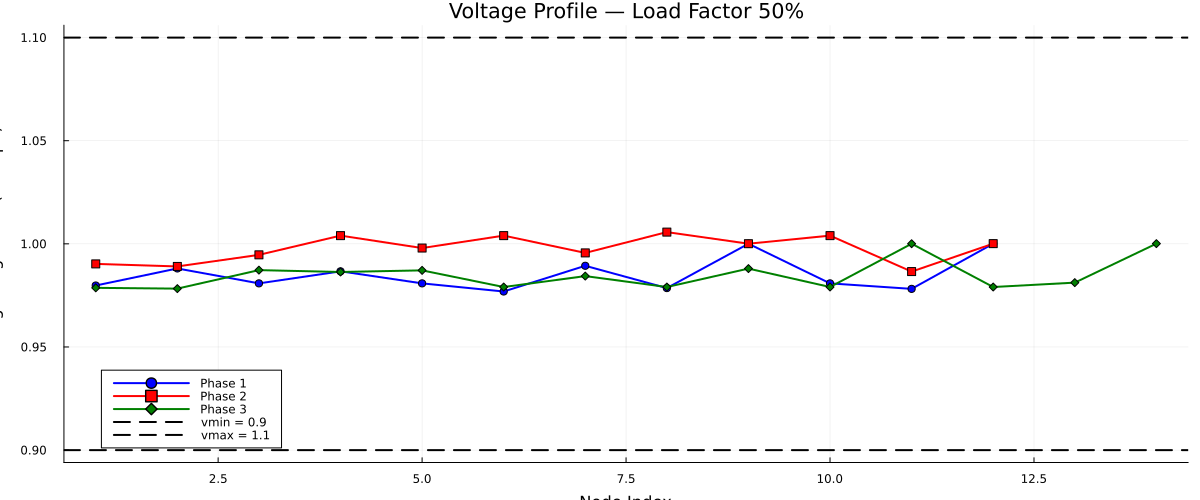

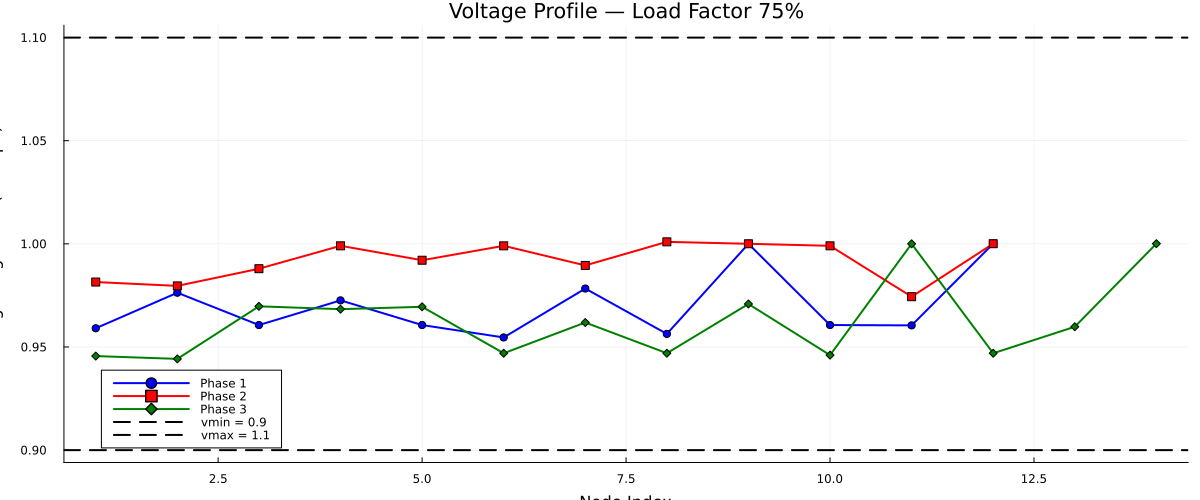

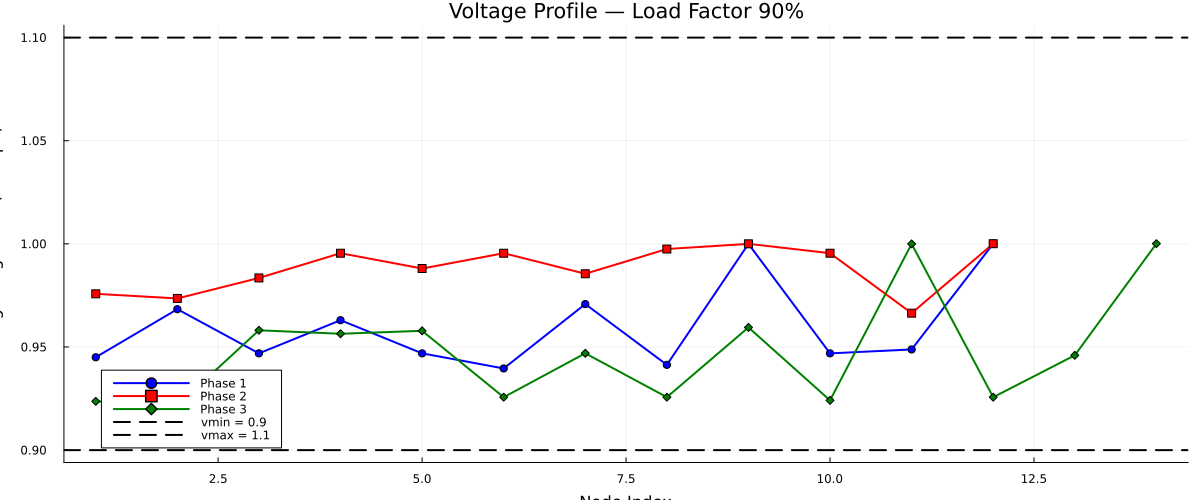

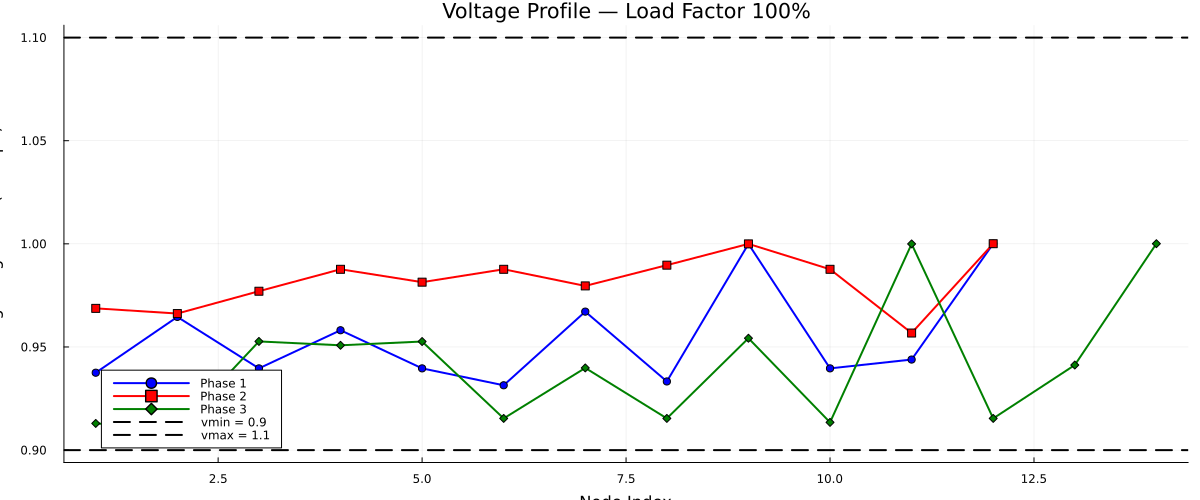

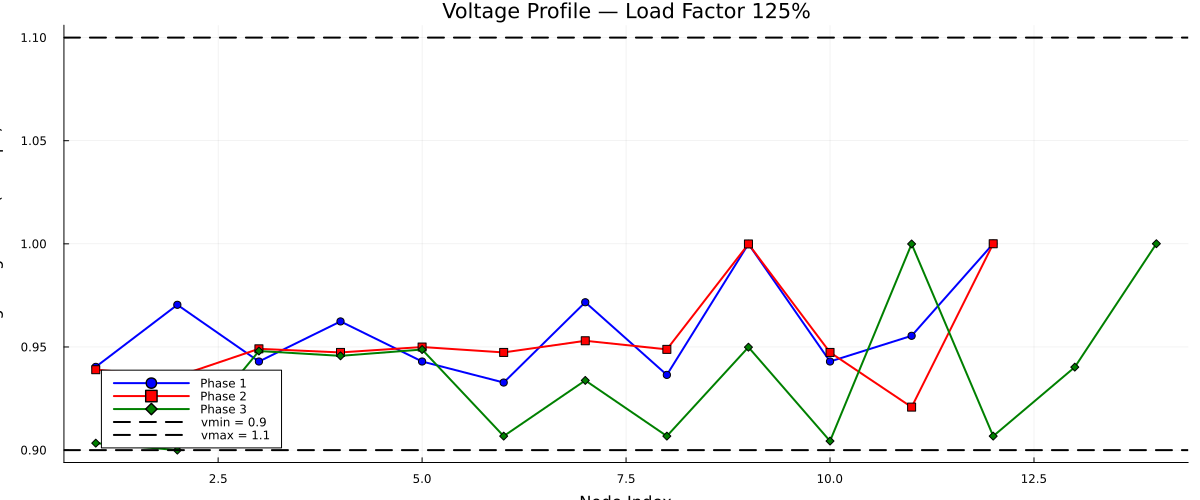

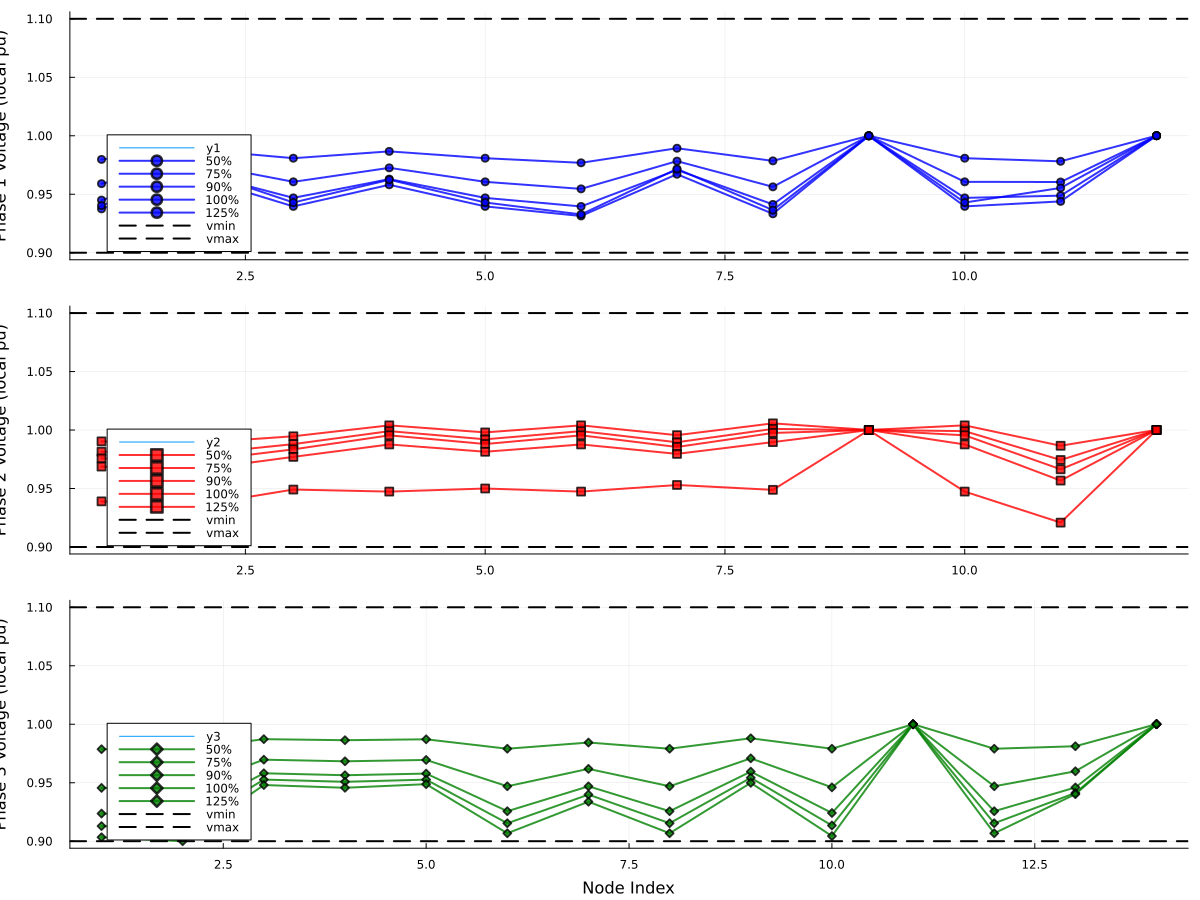

Plots generated.


In [15]:
using Plots
gr()

# ── Individual plots per load factor ───────────────────────────────────────
println("Generating voltage profile plots...")

plots_individual = Plots.Plot[]

for res in opf_results
    factor = res.factor
    r = res.result

    # Organize voltages by phase
    ph1_nodes = Int[]
    ph2_nodes = Int[]
    ph3_nodes = Int[]

    for i in 1:n_net
        bp = ybus.network_order[i]
        ph = bp.phase
        if ph == 1
            push!(ph1_nodes, i)
        elseif ph == 2
            push!(ph2_nodes, i)
        elseif ph == 3
            push!(ph3_nodes, i)
        end
    end

    vm1 = r.vmag_local[ph1_nodes]
    vm2 = r.vmag_local[ph2_nodes]
    vm3 = r.vmag_local[ph3_nodes]

    p = plot(size=(1200, 500),
             title="Voltage Profile — Load Factor $(Int(factor*100))%",
             xlabel="Node Index", ylabel="Voltage Magnitude (local pu)",
             legend=:bottomleft, grid=true)

    if !isempty(vm1)
        x1 = 1:length(vm1)
        plot!(p, x1, vm1, marker=:circle, label="Phase 1", color=:blue, linewidth=2)
    end
    if !isempty(vm2)
        x2 = 1:length(vm2)
        plot!(p, x2, vm2, marker=:square, label="Phase 2", color=:red, linewidth=2)
    end
    if !isempty(vm3)
        x3 = 1:length(vm3)
        plot!(p, x3, vm3, marker=:diamond, label="Phase 3", color=:green, linewidth=2)
    end

    # Voltage limits
    hline!(p, [vmin], linestyle=:dash, color=:black, linewidth=2, label="vmin = $(vmin)")
    hline!(p, [vmax], linestyle=:dash, color=:black, linewidth=2, label="vmax = $(vmax)")

    push!(plots_individual, p)
    display(p)
end

# ── Combined plot: all load factors on one subplot per phase ────────────────
p_combined = plot(3, 1, size=(1200, 900), layout=(3,1),
                  legend=:bottomleft, grid=true)

phase_colors = Dict(1 => :blue, 2 => :red, 3 => :green)
phase_markers = Dict(1 => :circle, 2 => :square, 3 => :diamond)

for phase in [1, 2, 3]
    # Get indices for this phase (same across all load factors)
    phase_indices = [i for i in 1:n_net if ybus.network_order[i].phase == phase]

    for res in opf_results
        factor = res.factor
        r = res.result
        vm_phase = r.vmag_local[phase_indices]

        if !isempty(vm_phase)
            plot!(p_combined[phase], 1:length(vm_phase), vm_phase,
                  marker=phase_markers[phase], label="$(Int(factor*100))%",
                  color=phase_colors[phase], linewidth=2, alpha=0.8)
        end
    end

    # Voltage limits on each subplot
    hline!(p_combined[phase], [vmin], linestyle=:dash, color=:black, linewidth=2, label="vmin")
    hline!(p_combined[phase], [vmax], linestyle=:dash, color=:black, linewidth=2, label="vmax")

    ylabel!(p_combined[phase], "Phase $(phase) Voltage (local pu)")
    if phase == 3
        xlabel!(p_combined[phase], "Node Index")
    end
end

display(p_combined)
println("Plots generated.")
